In [9]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


In [10]:
# Step 2: Load the dataset
data = pd.read_csv('//content/AirPassengers.csv')
print(data.head())

     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


In [11]:
# Convert 'Month' column to datetime
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

In [13]:
# Step 3: Normalize the 'Passengers' column
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[['#Passengers']])


In [14]:
# Step 4: Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 12  # use past 12 months to predict the next month
X, y = create_sequences(data_scaled, seq_length)


In [15]:
# Step 5: Split into train and test sets
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 6: Build the LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)

# Step 8: Make predictions
y_pred = model.predict(X_test)

# Inverse transform to get actual values
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - loss: 0.0862 - val_loss: 0.2870
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0723 - val_loss: 0.2059
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0454 - val_loss: 0.1339
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0276 - val_loss: 0.0706
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0169 - val_loss: 0.0282
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0094 - val_loss: 0.0208
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0120 - val_loss: 0.0219
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0112 - val_loss: 0.0207
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0087 - val_loss: 0.0266
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0078 - val_loss: 0.0313
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0082 - val_loss: 0.0285
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0101 - val_l

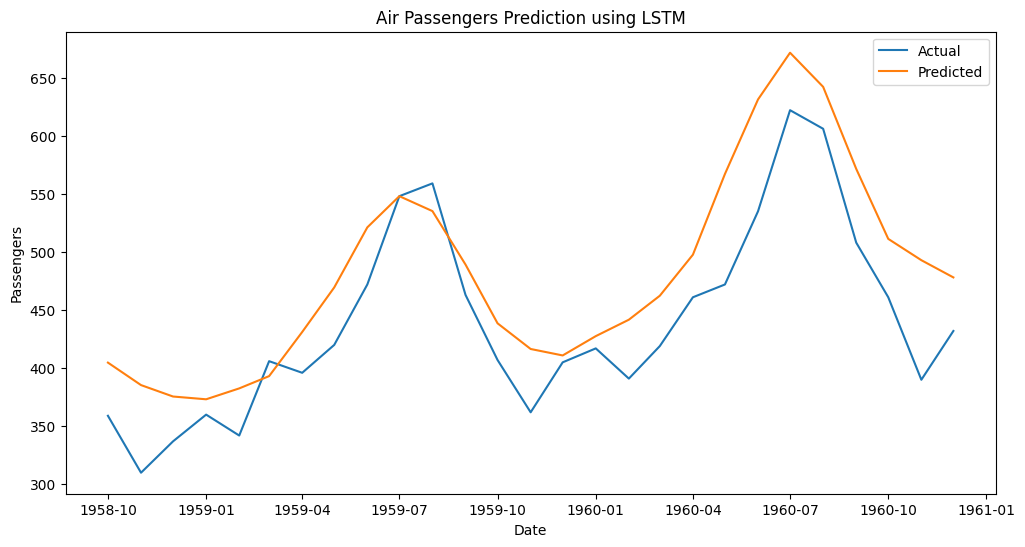

In [17]:
# Step 9: Plot results
plt.figure(figsize=(12,6))
plt.plot(data.index[-len(y_test):], y_test_inv, label='Actual')
plt.plot(data.index[-len(y_test):], y_pred_inv, label='Predicted')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.title('Air Passengers Prediction using LSTM')
plt.show()